In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.metrics import silhouette_samples

In [2]:
df = pd.read_csv("dataset_cleaned.csv")

In [3]:
wcss = [] 
silhouette_scores = []
db_scores = []

In [4]:
k_range = range(2, 20)

In [5]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(df)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df, cluster_labels))
    db_scores.append(davies_bouldin_score(df, cluster_labels))

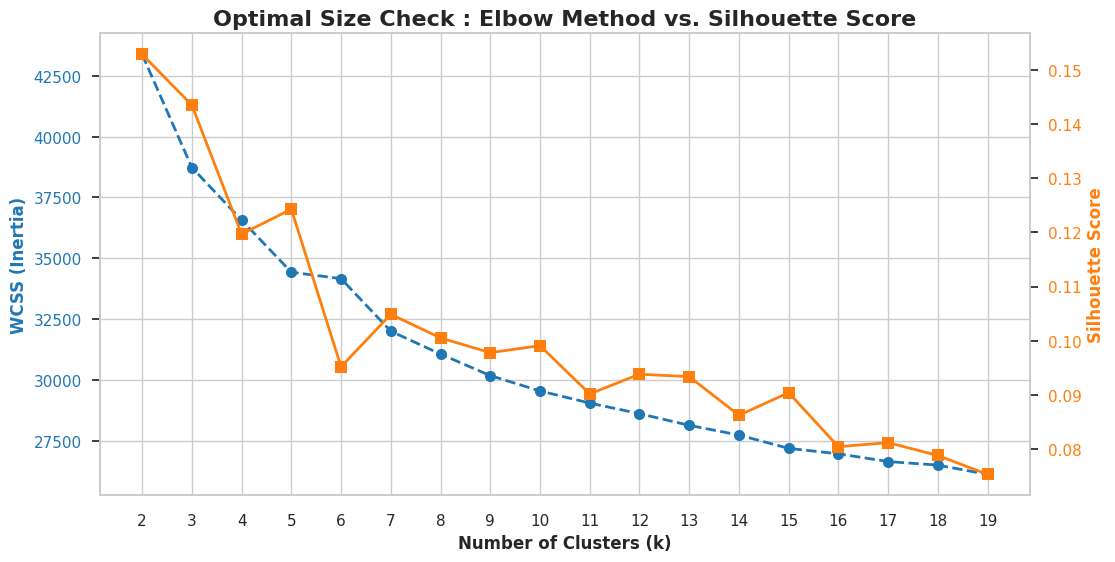

In [8]:
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))
color1 = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
ax1.set_ylabel('WCSS (Inertia)', color=color1, fontsize=12, fontweight='bold')
ax1.plot(k_range, wcss, marker='o', linestyle='--', color=color1, linewidth=2, markersize=8)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()  
color2 = 'tab:orange'
ax2.set_ylabel('Silhouette Score', color=color2, fontsize=12, fontweight='bold')
ax2.plot(k_range, silhouette_scores, marker='s', linestyle='-', color=color2, linewidth=2, markersize=8)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Optimal Size Check : Elbow Method vs. Silhouette Score', fontsize=16, fontweight='bold')
plt.xticks(k_range)
plt.grid(False) 
plt.show()

In [10]:
metrics_df = pd.DataFrame({
    'k': k_range,
    'Silhouette Score': silhouette_scores,
    'Davies-Bouldin ': db_scores
})
print(metrics_df)

     k  Silhouette Score  Davies-Bouldin 
0    2          0.152914         2.219285
1    3          0.143543         2.070444
2    4          0.119699         2.247255
3    5          0.124294         1.914616
4    6          0.095164         2.448281
5    7          0.104873         2.101356
6    8          0.100507         2.174932
7    9          0.097782         2.200476
8   10          0.099074         2.254418
9   11          0.090154         2.291920
10  12          0.093794         2.333451
11  13          0.093349         2.171336
12  14          0.086205         2.323710
13  15          0.090379         2.134088
14  16          0.080394         2.197007
15  17          0.081152         2.183806
16  18          0.078773         2.264155
17  19          0.075278         2.165642


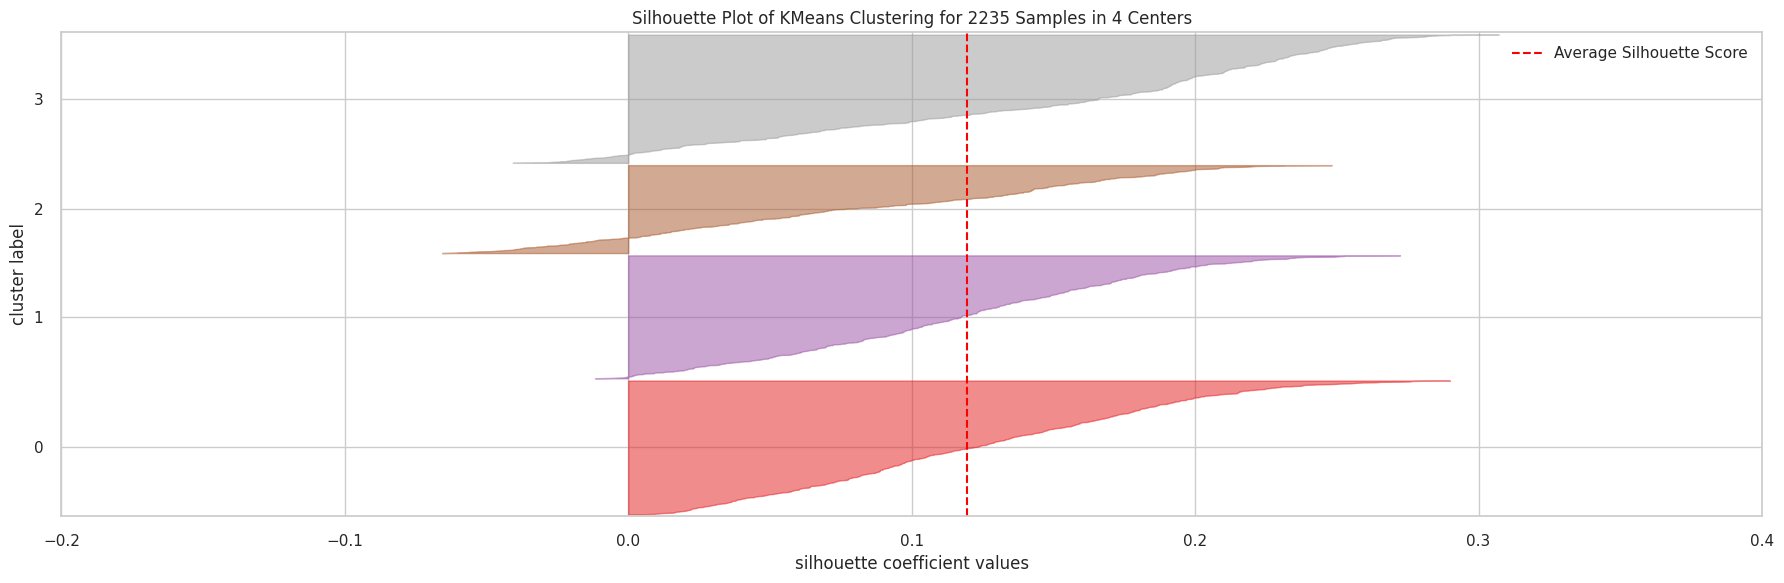

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 2235 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [27]:
k = 4
fig, ax = plt.subplots(figsize=(18, 6))
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
visualizer = SilhouetteVisualizer(kmeans, ax=ax, force_model=True)
visualizer.fit(df.values)       
visualizer.finalize()    
ax.set_title(f"Silhouette Plot for k = {k}", fontsize=14, fontweight='bold')
plt.tight_layout()
visualizer.show()

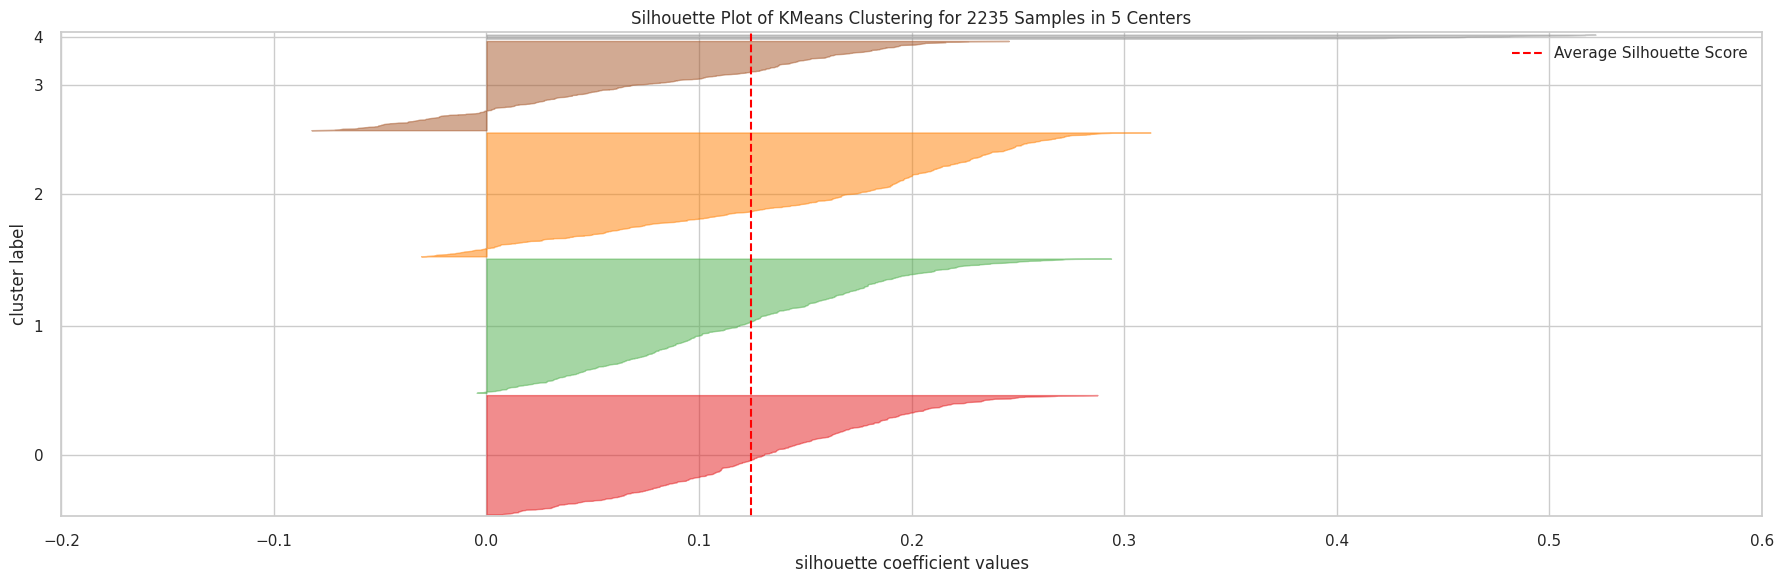

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 2235 Samples in 5 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [30]:
k = 5
fig, ax = plt.subplots(figsize=(18, 6))
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
visualizer = SilhouetteVisualizer(kmeans, ax=ax, force_model=True)
visualizer.fit(df.values)       
visualizer.finalize()    
ax.set_title(f"Silhouette Plot for k = {k}", fontsize=14, fontweight='bold')
plt.tight_layout()
visualizer.show()

In [28]:
#for k = 4
kmeans_labels = kmeans.labels_
cluster_sizes = np.bincount(kmeans_labels)
sample_silhouette_values = silhouette_samples(df.values, kmeans_labels)
per_cluster_silhouette = []
for i in range(k):
    ith_cluster_silhouette_values = sample_silhouette_values[kmeans_labels == i]
    per_cluster_silhouette.append(ith_cluster_silhouette_values.mean())
cluster_summary = pd.DataFrame({
    'Cluster': range(k),
    'Number of Customers': cluster_sizes,
    'Average Silhouette Score': per_cluster_silhouette
})
print(cluster_summary)

   Cluster  Number of Customers  Average Silhouette Score
0        0                  632                  0.123907
1        1                  581                  0.115954
2        2                  416                  0.082280
3        3                  606                  0.144587


In [31]:
#for k = 5
kmeans_labels = kmeans.labels_
cluster_sizes = np.bincount(kmeans_labels)
sample_silhouette_values = silhouette_samples(df.values, kmeans_labels)
per_cluster_silhouette = []
for i in range(k):
    ith_cluster_silhouette_values = sample_silhouette_values[kmeans_labels == i]
    per_cluster_silhouette.append(ith_cluster_silhouette_values.mean())
cluster_summary = pd.DataFrame({
    'Cluster': range(k),
    'Number of Customers': cluster_sizes,
    'Average Silhouette Score': per_cluster_silhouette
})
print(cluster_summary)

   Cluster  Number of Customers  Average Silhouette Score
0        0                  566                  0.131002
1        1                  637                  0.118787
2        2                  588                  0.149076
3        3                  424                  0.073374
4        4                   20                  0.460777


k=5 is the most optimal cluster size as seen from the above analysis!